In [103]:
# -*- coding: utf-8 -*-
"""
Created on Thu May 21 13:37:00 2025

@author: CKolay
"""
#%% Import opensees and others
import openseespy.opensees as ops
# import opensees as ops  # local compilation
import opsvis as opsv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# import sys
# sys.path.append('../')
# from FiberSectionForceDeformation import MomentCurvaturePy2D
# import os
# os.system('clear')
# plt.close("all")

#%% Define material and section properties
P =-46000.0 # Axial force
Mz =55624 # Moment about z-axis
My = 14923 # Moment about y-axis
B = 3.0
D = 3.5
db = 0.100
pi =3.141592653589793
Ab = pi*db**2/4

# Number of subdivisions (fibers) in the y direction (fiber width = H/Ny)
Ny = 50
# Number of subdivisions (fibers) in the z-direction  (fiber width = B/Nz)
Nz = 50

#  Number of bolts along z-direction, including the corner bolts
Nbz = 10
#  Number of bolts along y-direction, excluding the corner bolts
Nby = 7

Nb = 2*(Nbz+Nby)

ed = 0.2

fy = 1000000.0 # High value so that no yielding occurs
Es = 200.0*10**6
fck = 50.0
Ec = 5000*np.sqrt(fck)*1e3

ConcMatTag = 1
SteelMatTag = 2



In [104]:
#%% Wipe and create model
ops.wipe()
ops.model('basic', '-ndm', 3, '-ndf', 6)  # frame 3D
# Define two nodes at (0,0)
ops.node(1, 0.0, 0.0, 0.0)
ops.node(2, 0.0, 0.0, 0.0)

# Fix all degrees of freedom except axial and bending
ops.fix(1, 1, 1, 1, 1, 1, 1)
ops.fix(2, 0, 1, 1, 1, 0, 0)

# No tension concrete material
ops.uniaxialMaterial('ENT',ConcMatTag,Ec)

# Tension only bolt material
ops.uniaxialMaterial('ElasticPPGap', SteelMatTag, Es, fy, 0.0, 0.0)


[['section', 'Fiber', 1, '-GJ', 1000000.0], ['patch', 'rect', 1, 50, 50, -1.75, -1.5, 1.75, 1.5], ['layer', 'straight', 2, 10, 0.007853981633974483, 1.55, 1.3, 1.55, -1.3], ['layer', 'straight', 2, 7, 0.007853981633974483, 1.1625, -1.3, -1.1625, -1.3], ['layer', 'straight', 2, 10, 0.007853981633974483, -1.55, -1.3, -1.55, 1.3], ['layer', 'straight', 2, 7, 0.007853981633974483, -1.1625, 1.3, 1.1625, 1.3]]


(np.float64(1.65), np.float64(-1.65), np.float64(-1.925), np.float64(1.925))

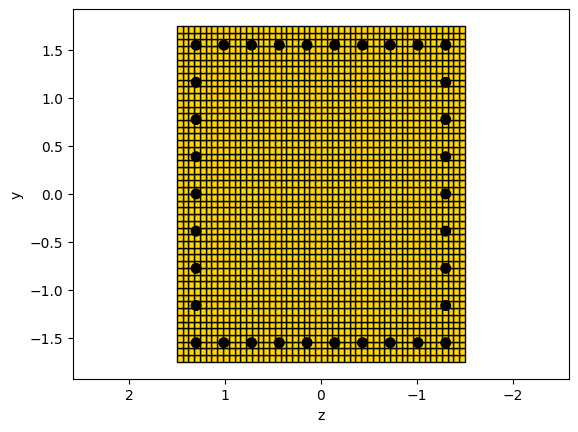

In [105]:

# some variables derived from the parameters
y1 = D/2.0
z1 = B/2.0

dy = (D-2*ed)/(Nby+1)
y2 = y1-ed-dy
secTag = 1

#ops.section(secType, secTag, *secArgs)¶
fib_sec_CFST = [['section','Fiber',secTag,'-GJ',1.0e6],
    # Create the concrete core fibers
    ['patch', 'rect', ConcMatTag, Ny, Nz, -y1, -z1, y1, z1],
    ['layer', 'straight', SteelMatTag, Nbz, Ab, y1-ed, z1-ed, y1-ed, ed-z1], # Top
    ['layer', 'straight', SteelMatTag, Nby, Ab, y2, ed-z1, -y2, ed-z1], # Right column
    ['layer', 'straight', SteelMatTag, Nbz, Ab, ed-y1, ed-z1, ed-y1, z1-ed], # Bottom
    ['layer', 'straight', SteelMatTag, Nby, Ab, -y2, z1-ed, y2, z1-ed] # Left column
    ]

matcolor = ['gold','lightgrey', 'gold', 'm', 'r', 'w', 'w']
print(fib_sec_CFST)
opsv.plot_fiber_section(fib_sec_CFST, matcolor=matcolor)
plt.axis('equal')



In [106]:
opsv.fib_sec_list_to_cmds(fib_sec_CFST)


In [107]:
# Define element
#                             tag ndI ndJ  secTag
ops.element('zeroLengthSection',  1,   1,   2,  secTag)

#%% Record stress-strain response in bolts and get bolt forces
def get_straight_layer_coords(n_fibers, yI, zI, yJ, zJ):
    ys = np.linspace(yI, yJ, n_fibers)
    zs = np.linspace(zI, zJ, n_fibers)
    return list(zip(ys, zs))

# Define all steel fiber layers
steel_fiber_coords = []

# Top bolt column
steel_fiber_coords += get_straight_layer_coords(Nbz, y1-ed, z1-ed, y1-ed, ed-z1)
# Right bolt column
steel_fiber_coords += get_straight_layer_coords(Nby, y2, ed-z1, -y2, ed-z1)
# Bottom bolt column
steel_fiber_coords += get_straight_layer_coords(Nbz, ed-y1, ed-z1, ed-y1, z1-ed)
# Left bolt column
steel_fiber_coords += get_straight_layer_coords(Nby, -y2, z1-ed, y2, z1-ed)

# Print coordinates
for i, (y, z) in enumerate(steel_fiber_coords, 1):
    print(f"Steel Fiber {i}: y = {y:.3f}, z = {z:.3f}")


Steel Fiber 1: y = 1.550, z = 1.300
Steel Fiber 2: y = 1.550, z = 1.011
Steel Fiber 3: y = 1.550, z = 0.722
Steel Fiber 4: y = 1.550, z = 0.433
Steel Fiber 5: y = 1.550, z = 0.144
Steel Fiber 6: y = 1.550, z = -0.144
Steel Fiber 7: y = 1.550, z = -0.433
Steel Fiber 8: y = 1.550, z = -0.722
Steel Fiber 9: y = 1.550, z = -1.011
Steel Fiber 10: y = 1.550, z = -1.300
Steel Fiber 11: y = 1.163, z = -1.300
Steel Fiber 12: y = 0.775, z = -1.300
Steel Fiber 13: y = 0.388, z = -1.300
Steel Fiber 14: y = 0.000, z = -1.300
Steel Fiber 15: y = -0.387, z = -1.300
Steel Fiber 16: y = -0.775, z = -1.300
Steel Fiber 17: y = -1.163, z = -1.300
Steel Fiber 18: y = -1.550, z = -1.300
Steel Fiber 19: y = -1.550, z = -1.011
Steel Fiber 20: y = -1.550, z = -0.722
Steel Fiber 21: y = -1.550, z = -0.433
Steel Fiber 22: y = -1.550, z = -0.144
Steel Fiber 23: y = -1.550, z = 0.144
Steel Fiber 24: y = -1.550, z = 0.433
Steel Fiber 25: y = -1.550, z = 0.722
Steel Fiber 26: y = -1.550, z = 1.011
Steel Fiber 27: y 

In [108]:
for i, (y, z) in enumerate(steel_fiber_coords, 1):
    ops.recorder('Element', '-file', f'fiber_{i}.txt', '-ele', secTag, 'section', 'fiber', y, z, SteelMatTag,'stressStrain')

fibLoc = D/2-ed
ops.recorder('Element','-ele',1,'-file','BoltFiber.out','section','fiber', -fibLoc, 0,SteelMatTag,'stressStrain')

#%% Record bearing pressure at four corners
ops.recorder('Element','-ele',1,'-file','BearingP1.out','section','fiber', y1, z1,ConcMatTag,'stressStrain')
ops.recorder('Element','-ele',1,'-file','BearingP2.out','section','fiber', y1, -z1,ConcMatTag,'stressStrain')
ops.recorder('Element','-ele',1,'-file','BearingP3.out','section','fiber', -y1, -z1,ConcMatTag,'stressStrain')
ops.recorder('Element','-ele',1,'-file','BearingP4.out','section','fiber', -y1, z1,ConcMatTag,'stressStrain')


233

In [ ]:

#%% Define constant axial load
ops.timeSeries('Constant', 1)
ops.pattern('Plain', 1, 1)
ops.load(2, P, 0.0, 0.0, 0.0, My, Mz)

# Define analysis parameters
ops.integrator('LoadControl', 0.0)
ops.system('SparseGeneral', '-piv')
ops.test('NormUnbalance', 1e-9, 10)
ops.numberer('Plain')
ops.constraints('Plain')
ops.algorithm('Newton')
ops.analysis('Static')

In [110]:
# Do one analysis for constant axial load
ops.analyze(1)

0

In [111]:
print(f'P = {P} and Mz = {Mz} applied')

#%% Get forces in each bolt and write to an excel file
fiber_forces = []
bolt_stress = []
bolt_strain = []
# --- Loop through each fiber file ---
for i in range(1, Nb + 1):
    filename = f"fiber_{i}.txt"
    bolt_data = np.loadtxt(filename)  # shape: (n_steps,)
    bolt_stress.append(bolt_data[0])
    bolt_strain.append(bolt_data[1])
    force = bolt_data[0] * Ab
    fiber_forces.append(force)

# Convert to numpy array for further processing
# shape: (num_fibers, n_steps)
fiber_forces = np.array(fiber_forces)
bolt_stress = np.array(bolt_stress)
bolt_strain = np.array(bolt_strain)


combined_data = []

for i, (y, z) in enumerate(steel_fiber_coords):
    row = [y, z,         fiber_forces[i],   # <-- scalar
        bolt_stress[i],    # <-- scalar
        bolt_strain[i],    # <-- scalar
        ]
    combined_data.append(row)

combined_data = np.array(combined_data)  # shape: (n_fibers, 2 + n_steps)
max_bolt_force = np.max(combined_data[:,2])
print("Maximum bolt force:", (max_bolt_force),"kN")
# Assuming `combined_data` is a NumPy array of shape (n_fibers, 2 + n_steps)
# from earlier step, and:
# - First column: y
# - Second column: z
# - Rest: forces over time

n_steps = combined_data.shape[1] - 2

# Create column names
columns = ['y (m)', 'z (m)', 'Force (kN)', 'Stress', 'Strain']

# Convert to DataFrame
df = pd.DataFrame(combined_data, columns=columns)

# Write to Excel
df.to_excel('Bolt_Forces.xlsx', index=False)


P = -46000.0 and Mz = 55624 applied
Maximum bolt force: 493.59682755590416 kN


In [112]:
for e,i in enumerate(bolt_stress):
    print("each ", e+1, " Stress ", i)

each  1  Stress  0.0
each  2  Stress  0.0
each  3  Stress  0.0
each  4  Stress  0.0
each  5  Stress  0.0
each  6  Stress  0.0
each  7  Stress  0.0
each  8  Stress  0.0
each  9  Stress  0.0
each  10  Stress  0.0
each  11  Stress  0.0
each  12  Stress  0.0
each  13  Stress  0.0
each  14  Stress  0.0
each  15  Stress  0.0
each  16  Stress  0.0
each  17  Stress  8471.51
each  18  Stress  23483.5
each  19  Stress  27857.2
each  20  Stress  32230.9
each  21  Stress  36604.6
each  22  Stress  40978.3
each  23  Stress  45352.0
each  24  Stress  49725.7
each  25  Stress  54099.3
each  26  Stress  58473.0
each  27  Stress  62846.7
each  28  Stress  47834.7
each  29  Stress  32822.6
each  30  Stress  17810.6
each  31  Stress  2798.56
each  32  Stress  0.0
each  33  Stress  0.0
each  34  Stress  0.0


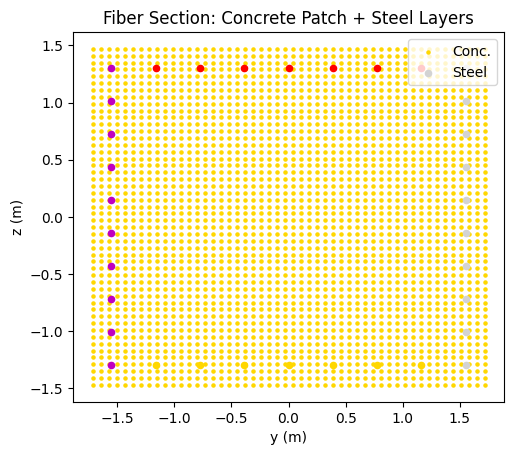

In [113]:
import numpy as np
import matplotlib.pyplot as plt

y1 = D/2.0
z1 = B/2.0
dy = (D - 2*ed) / (Nby + 1)
y2 = y1 - ed - dy

fib_sec_CFST = [
    ['patch', 'rect', ConcMatTag, Ny, Nz, -y1, -z1, y1, z1],
    ['layer', 'straight', SteelMatTag, Nbz, Ab,  y1-ed,  z1-ed,  y1-ed, ed-z1],  # Top
    ['layer', 'straight', SteelMatTag, Nby, Ab,  y2,    ed-z1,  -y2,   ed-z1],  # Right
    ['layer', 'straight', SteelMatTag, Nbz, Ab,  ed-y1, ed-z1, ed-y1,  z1-ed],  # Bottom
    ['layer', 'straight', SteelMatTag, Nby, Ab, -y2,     z1-ed,  y2,    z1-ed]   # Left
]
 
fig, ax = plt.subplots()
colors = matcolor 

for i, sec in enumerate(fib_sec_CFST):
    kind = sec[0]
    if kind == 'patch':
        _, _, matTag, n_y, n_z, y_min, z_min, y_max, z_max = sec
        ys = np.linspace(y_min + (y_max-y_min)/(2*n_y),
                         y_max - (y_max-y_min)/(2*n_y),
                         n_y)
        zs = np.linspace(z_min + (z_max-z_min)/(2*n_z),
                         z_max - (z_max-z_min)/(2*n_z),
                         n_z)
        YY, ZZ = np.meshgrid(ys, zs)
        ax.scatter(YY.flatten(), ZZ.flatten(),
                   s=5, color=colors[i], label='Conc.' if i==0 else "")
    elif kind == 'layer':
        _, _, matTag, n_fib, area, yI, zI, yJ, zJ = sec
        ys = np.linspace(yI, yJ, n_fib)
        zs = np.linspace(zI, zJ, n_fib)
        ax.scatter(ys, zs,
                   s=20, color=colors[i],
                   label='Steel' if matTag==SteelMatTag and i==1 else "")
ax.set_aspect('equal')
ax.set_xlabel('y (m)')
ax.set_ylabel('z (m)')
ax.set_title('Fiber Section: Concrete Patch + Steel Layers')
ax.legend(loc='upper right')
plt.show()


C:\Users\Vishal\AppData\Local\Temp\ipykernel_28064\3535091857.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


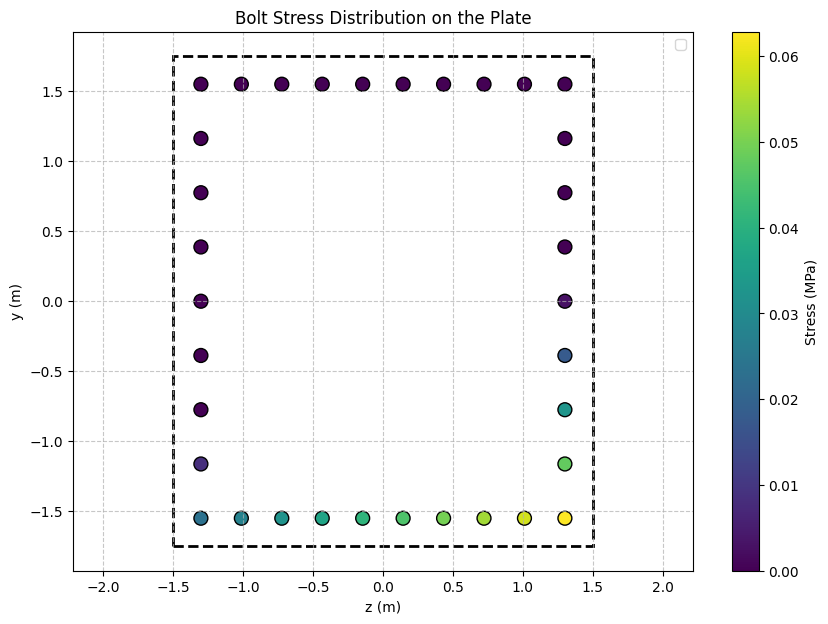

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

df = pd.read_excel('Bolt_Forces.xlsx')
y = df['y (m)']
z = df['z (m)']
stress_pa = df['Stress'] 
stress_mpa = stress_pa / 1e6 
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(z, y, c=stress_mpa, cmap='viridis', s=100, edgecolor='k')
plate_rect = patches.Rectangle(
    (-1.5, -1.75), 3, 3.5,  # (x, y), width, height
    linewidth=2, edgecolor='black', facecolor='none',
    linestyle='--'
)
ax.add_patch(plate_rect)
plt.colorbar(scatter, label='Stress (MPa)')
ax.set_xlabel('z (m)')
ax.set_ylabel('y (m)')
ax.set_title('Bolt Stress Distribution on the Plate')
ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.8, 1.8)
ax.grid(True, linestyle='--', alpha=0.7)
plt.axis('equal')
# plt.tight_layout()
plt.legend()
plt.show()

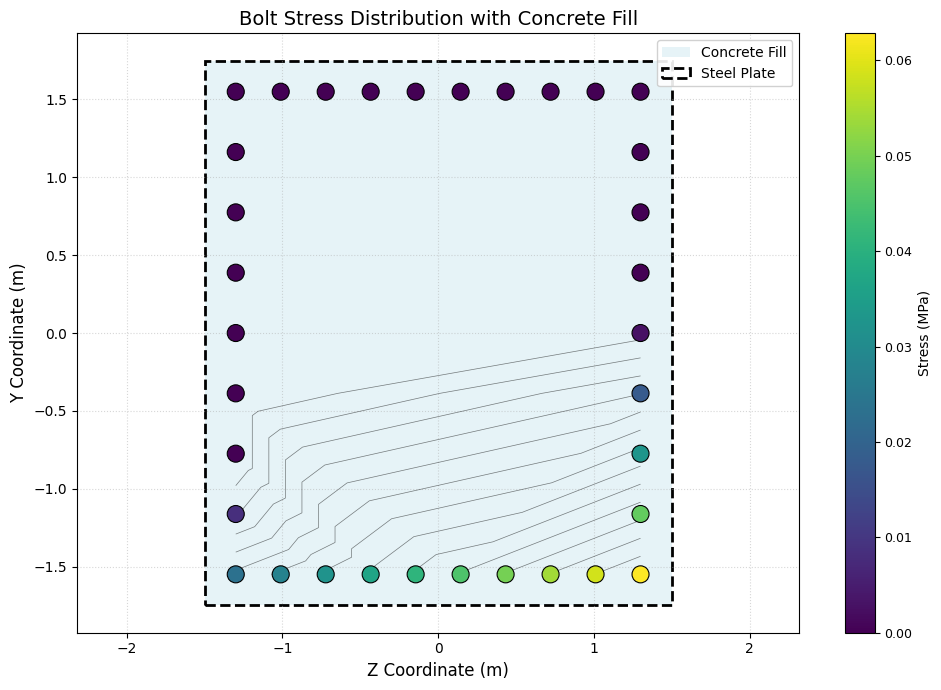

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.tri as tri  

df = pd.read_excel('Bolt_Forces.xlsx')

y = df['y (m)']
z = df['z (m)']
stress_mpa = df['Stress'] / 1e6
B = 3.0 
D = 3.5 
fig, ax = plt.subplots(figsize=(10, 7))
concrete_fill = patches.Rectangle(
    (-B/2, -D/2), B, D,
    linewidth=0, edgecolor='none', 
    facecolor='lightblue', alpha=0.3,
    label='Concrete Fill'
)
ax.add_patch(concrete_fill)

plate_outline = patches.Rectangle(
    (-B/2, -D/2), B, D,
    linewidth=2, edgecolor='black', facecolor='none',
    linestyle='--', label='Steel Plate'
)
ax.add_patch(plate_outline)

scatter = ax.scatter(z, y, c=stress_mpa, 
                    cmap='viridis', s=150, 
                    edgecolor='k', linewidth=0.8,
                    zorder=3)
cbar = plt.colorbar(scatter, label='Stress (MPa)')
cbar.ax.tick_params(labelsize=9)
triang = tri.Triangulation(z, y)
levels = np.linspace(stress_mpa.min(), stress_mpa.max(), 15)
ax.tricontour(triang, stress_mpa, levels=levels, 
             colors='k', linewidths=0.5, alpha=0.5)
ax.set_xlabel('Z Coordinate (m)', fontsize=12)
ax.set_ylabel('Y Coordinate (m)', fontsize=12)
ax.set_title('Bolt Stress Distribution with Concrete Fill', fontsize=14)
ax.set_xlim(-B/2*1.1, B/2*1.1)
ax.set_ylim(-D/2*1.1, D/2*1.1)
ax.grid(True, linestyle=':', alpha=0.5)
plt.axis('equal')
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()

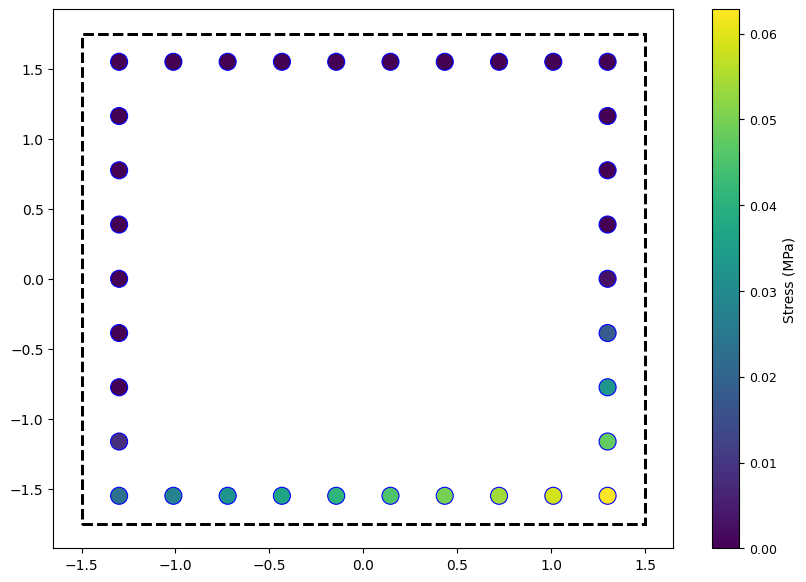

In [116]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.tri as tri
import numpy as np
import pandas as pd

df = pd.read_excel('Bolt_Forces.xlsx')

y = df['y (m)']
z = df['z (m)']
stress = df['Stress'] / 1e6
B = 3.0
D = 3.5

fig, ax = plt.subplots(figsize=(10, 7))

concrete_fill = patches.Rectangle(
    (-B/2, -D/2), B, D,
    linewidth=2, edgecolor='black', facecolor='none',
    linestyle='--', label='Steel Plate'
)

ax.add_patch(concrete_fill)

plate_outline = patches.Rectangle(
    (-B/2, -D/2), B, D,
    linewidth=2, edgecolor='black', facecolor='none',
    linestyle='--', label='Steel Plate'
)
ax.add_patch(plate_outline)
scatter = ax.scatter(z, y, c=stress, 
                    cmap='viridis', s=150, 
                    edgecolor='b', linewidth=0.8,
                    zorder=3)

cbar = plt.colorbar(scatter, label='Stress (MPa)')
cbar.ax.tick_params(labelsize=9)
plt.show()



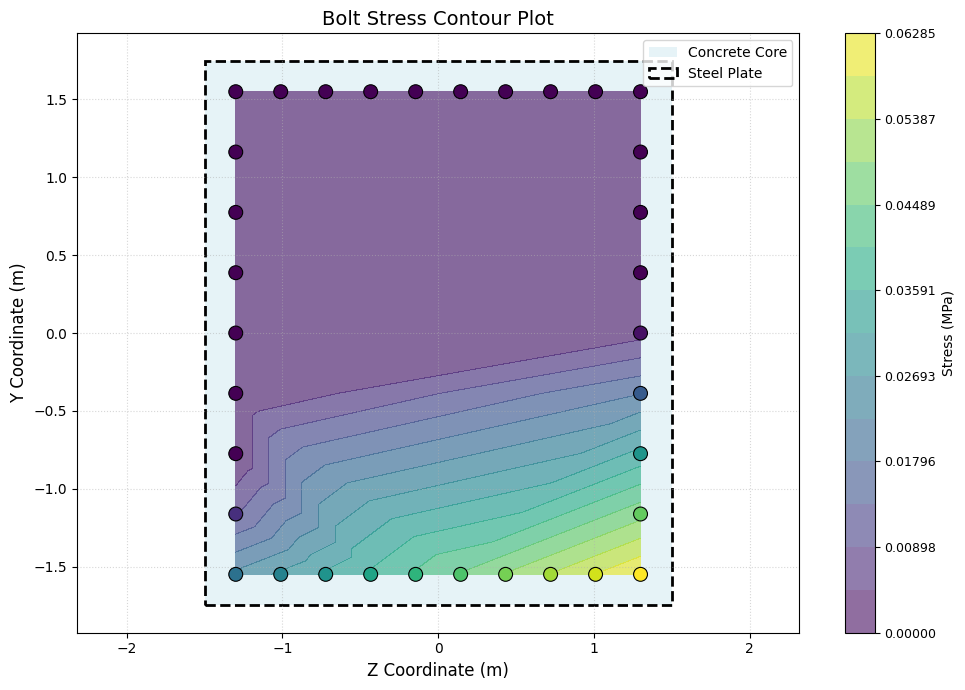

In [117]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.tri as tri
import numpy as np
import pandas as pd

df = pd.read_excel('Bolt_Forces.xlsx')
y = df['y (m)']
z = df['z (m)']
stress = df['Stress'] / 1e6 
B = 3.0 
D = 3.5  
fig, ax = plt.subplots(figsize=(10, 7))
concrete_fill = patches.Rectangle(
    (-B/2, -D/2), B, D,
    linewidth=0, 
    facecolor='lightblue', 
    alpha=0.3,  
    label='Concrete Core'
)
ax.add_patch(concrete_fill)

plate_outline = patches.Rectangle(
    (-B/2, -D/2), B, D,
    linewidth=2, 
    edgecolor='black', 
    facecolor='none',
    linestyle='--', 
    label='Steel Plate'
)
ax.add_patch(plate_outline)

triangulation = tri.Triangulation(z, y)
levels = np.linspace(stress.min(), stress.max(), 15)
contour = ax.tricontourf(triangulation, stress, levels=levels, cmap='viridis', alpha=0.6)

scatter = ax.scatter(z, y, c=stress, 
                    cmap='viridis', s=100, 
                    edgecolor='black', 
                    linewidth=0.8,
                    zorder=3)
cbar = plt.colorbar(contour, label='Stress (MPa)')
cbar.ax.tick_params(labelsize=9)
ax.set_xlabel('Z Coordinate (m)', fontsize=12)
ax.set_ylabel('Y Coordinate (m)', fontsize=12)
ax.set_title('Bolt Stress Contour Plot', fontsize=14)
ax.set_xlim(-B/2*1.1, B/2*1.1)
ax.set_ylim(-D/2*1.1, D/2*1.1)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='upper right')
plt.axis('equal')
plt.tight_layout()
plt.show()